In [5]:
!pip install seaborn


Mean: 36.923809523809524, Median: 36.0, Mode: 35, Variance: 83.45504878602223, Standard Deviation: 9.135373489136732, IQR: 13.0, Outliers: 0


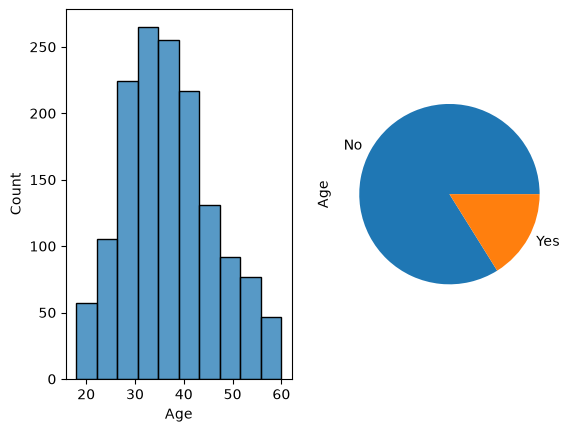

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv('/Users/rayquaza/Desktop/important/6th sem/ML/EDAibm_hr_employee-attrition.csv')

num=df.select_dtypes(include='number').columns
cat=df.select_dtypes(exclude='number').columns
n=input("Enter the number col")
if n in num:
    no=df[n]
    mean=no.mean()
    median=no.median()
    mode=no.mode()[0]
    var=no.var()
    std=no.std()
    q3=no.quantile(0.75)
    q1=no.quantile(0.25)
    iqr=q3-q1
    lb=q1-1.5*iqr
    ub=q3+1.5*iqr
    out=no[(no<lb) | (no>ub)]
    print(f"Mean: {mean}, Median: {median}, Mode: {mode}, Variance: {var}, Standard Deviation: {std}, IQR: {iqr}, Outliers: {len(out)}")
    plt.subplot(1,2,1)
    sns.histplot(no,bins=10)
    plt.subplot(1,2,2)
    sns.boxplot(no)
else:
    print(f"{n} is not a numerical column.")
c=input("Enter the cat col")
if c in cat:
    ca=df[c].value_counts()
    inp=input("Enter the pie or bar")
    if inp=='pie':
        ca.plot(kind='pie')
    if inp=='bar':
        ca.plot(kind='bar')
else:
    print('invalid')

Correlation:               petal_length  sepal_length
petal_length      1.000000      0.871754
sepal_length      0.871754      1.000000, 
Covariance:               petal_length  sepal_length
petal_length      3.116278      1.274315
sepal_length      1.274315      0.685694


<Axes: >

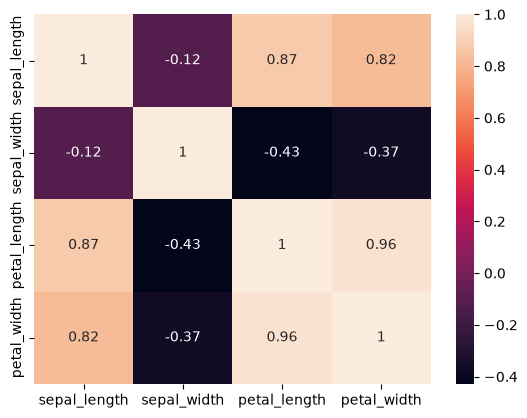

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=sns.load_dataset('iris')
y='petal_length'
x='sepal_length'
corr=df[['petal_length','sepal_length']].corr('pearson')
cov=df[['petal_length','sepal_length']].cov()
print(f"Correlation: {corr}, \nCovariance: {cov}")
ndf=df.iloc[:,:-1]
corr=ndf.corr()
cov=ndf.cov()
sns.heatmap(corr,annot=True)


In [19]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 6.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 7.2 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


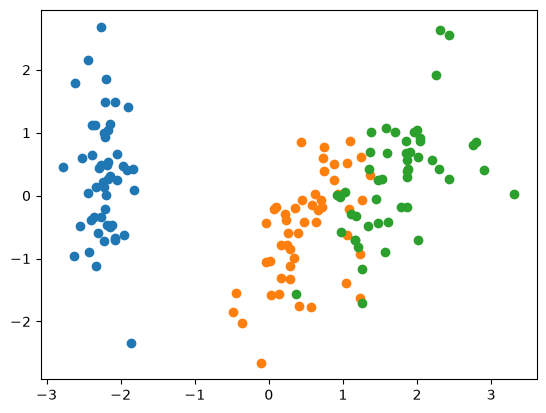

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
df=load_iris()
x=df.data
y=df.target
sc=StandardScaler()
x=sc.fit_transform(x)
pc=PCA(n_components=2)
p=pc.fit_transform(x)
pdf=pd.DataFrame(data=p,columns=['PC1','PC2'])  
pdf['species']=y
color= ['red','green','blue']
for i,color in zip([0,1,2],color):
    plt.scatter(
        pdf[pdf['species'] == i]['PC1'],
        pdf[pdf['species'] == i]['PC2']
    )
plt.plot()
plt.show()


In [34]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split as tts
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score as ass, f1_score as f1
df=load_iris()
x=df.data
y=df.target
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=43)
k_val=[1,3,5]
def nei(x_train,x_test,y_train,y_test,k_vals,weighted=False):
    results={}
    for k in k_vals:
        if weighted:
            knn=KNeighborsClassifier(n_neighbors=k,weights='distance')
        else:
            knn=KNeighborsClassifier(n_neighbors=k,weights='uniform')
        knn.fit(x_train,y_train)
        y_pred=knn.predict(x_test)
        acc=ass(y_test,y_pred)
        f11=f1(y_test,y_pred,average='weighted')
        results[k]={
            'acc':acc,
            'f1':f11
        }
    return results
w_mod=nei(x_train,x_test,y_train,y_test,k_val,weighted=True)
for k, w in w_mod.items():
    print(f'{k},{w["acc"]},{w["f1"]}')
nw_mod=nei(x_train,x_test,y_train,y_test,k_val,weighted=False)
for k, w in nw_mod.items():
    print(f'{k},{w["acc"]},{w["f1"]}')
for k in k_val:
    na=nw_mod[k]["acc"]
    w=w_mod[k]["acc"]
    print(f"{na},{w}")

1,1.0,1.0
3,1.0,1.0
5,1.0,1.0
1,1.0,1.0
3,1.0,1.0
5,1.0,1.0
1.0,1.0
1.0,1.0
1.0,1.0


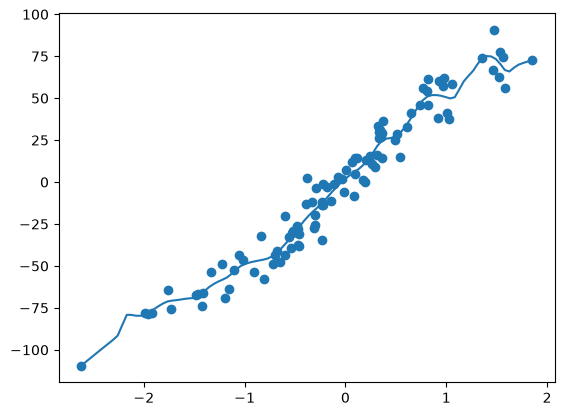

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression as mr
import numpy as np
x,y=mr(n_samples=100,n_features=1,noise=10,random_state=42)
y+=10*np.sin(x[:,0]*2)
x_test=np.linspace(x.max(),x.min(),100)
def lwr(x,y,q,tau=0.1):
    w=np.exp((-(x-q)**2).sum(axis=1)/(2*tau**2))
    wp=np.diag(w)
    x_b=np.c_[np.ones(len(x)),x]
    q_b=[1,q]
    the=np.linalg.lstsq(x_b.T @wp @x_b, x_b.T @wp @y, rcond=True)[0]
    return q_b @ the
tau=0.1
y_pred=[lwr(x,y,q,tau) for q in x_test]
plt.scatter(x,y)
plt.plot(x_test,y_pred)
plt.show()

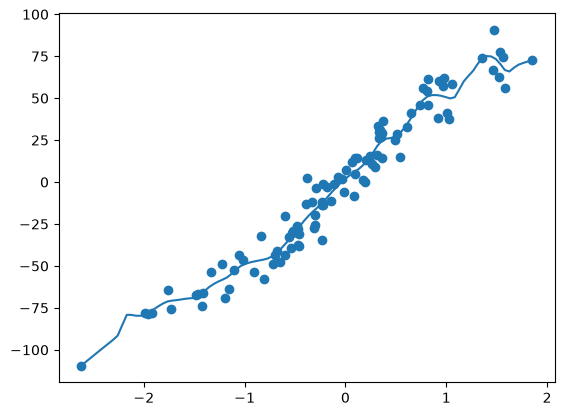

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression as mr
x,y=mr(n_samples=100,n_features=1,noise=10,random_state=42)
y+=10*np.sin(x[:,0]*2)
x_test=np.linspace(x.max(),x.min(),100)
def lwr(x,y,q,tau=0.1):
    w=np.exp((-(x-q)**2).sum(axis=1)/(2*tau**2))
    wp=np.diag(w)
    x_b=np.c_[np.ones(len(x)),x]
    q_b=[1,q]
    the=np.linalg.lstsq(x_b.T @wp @x_b, x_b.T @wp @y, rcond=True)[0]
    return q_b @the
tau=0.1
y_pred=[lwr(x,y,q,tau) for q in x_test]
plt.scatter(x,y)
plt.plot(x_test,y_pred)
plt.show()

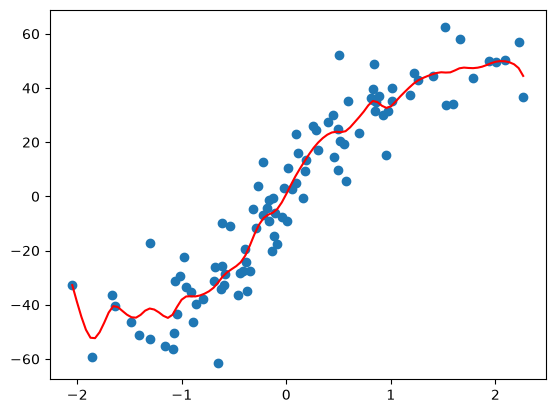

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression as mr
x,y=mr(n_samples=100,n_features=1,noise=10,random_state=43)
y+=10*np.sin(x[:,0]*2)
x_test=np.linspace(x.max(),x.min(),100)
def lwr(x,y,q,tau=0.1):
    w=np.exp((-(x-q)**2).sum(axis=1)/(2*tau**2))
    wp=np.diag(w)
    x_b=np.c_[np.ones(len(x)),x]
    q_b=[1,q]
    the=np.linalg.lstsq(x_b.T @wp @x_b, x_b.T @wp @y, rcond=True)[0]
    return q_b @the
tau=0.1
y_pred=[lwr(x,y,q,tau) for q in x_test]
plt.scatter(x,y)
plt.plot(x_test,y_pred,color='red')
plt.show()

Linear Regression - MSE: 43.901155943894686, R2 Score: 0.4946536683619652


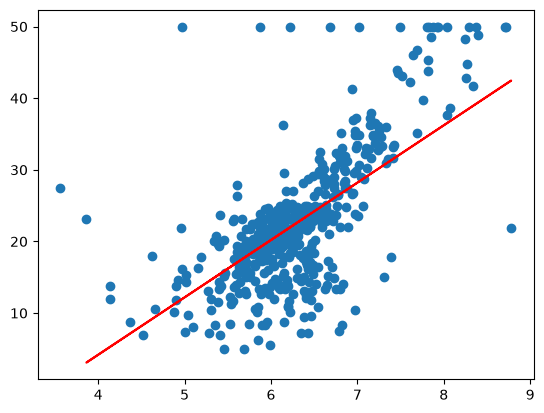

Polynomial Regression - MSE: 20.6335847509775, R2 Score: 0.6730004997997475


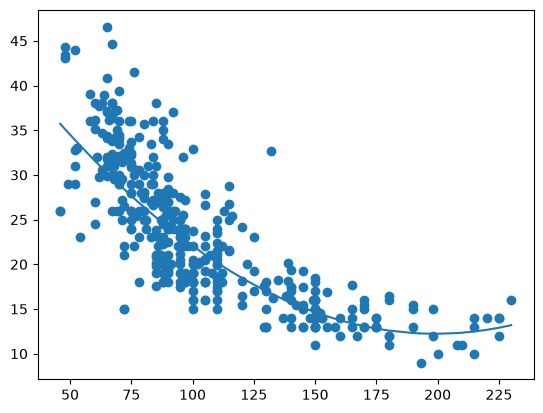

In [32]:
import numpy as mp
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error as mse, r2_score as r2
df_l=pd.read_csv('boston_housing_data.csv')
x1=df_l[['RM']];y1=df_l[['MEDV']];
x_test,x_train,y_test,y_train=tts(x1,y1,test_size=0.2,random_state=42)
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
mmse=mse(y_test,y_pred)
r2s=r2(y_test,y_pred)
print(f"Linear Regression - MSE: {mmse}, R2 Score: {r2s}")
plt.scatter(x1,y1)
plt.plot(x_test,y_pred,color='red')
plt.show()
df_p=pd.read_csv('auto-mpg.csv')
df_p[['horsepower']]=df_p[['horsepower']].replace('?',np.nan).astype(float)
df_p.dropna(inplace=True)
x2=df_p[['horsepower']]
y2=df_p[['mpg']]
x_test,x_train,y_test,y_train=tts(x2,y2,test_size=0.2,random_state=42)
p=PolynomialFeatures(degree=2)
x_train_p=p.fit_transform(x_train)
x_test_p=p.transform(x_test)
lr.fit(x_train_p,y_train)
y_pred=lr.predict(x_test_p)
mmse=mse(y_test,y_pred)
r2s=r2(y_test,y_pred)
print(f"Polynomial Regression - MSE: {mmse}, R2 Score: {r2s}")
plt.scatter(x2,y2)
sor=x_test.squeeze().argsort()
plt.plot(x_test.iloc[sor],y_pred[sor])
plt.show()

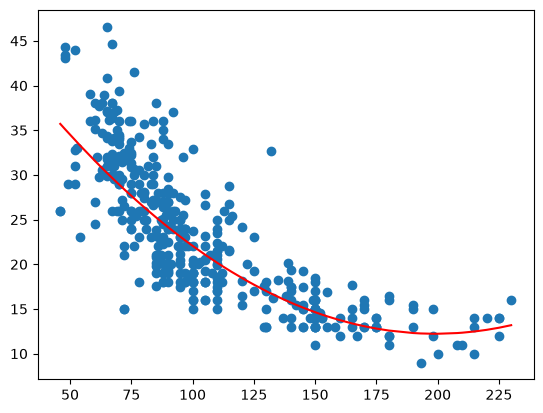

In [36]:
plt.scatter(x2,y2)
sor=x_test.squeeze().argsort()
plt.plot(x_test.iloc[sor],y_pred[sor],color='red')
plt.show()

              precision    recall  f1-score   support

           0       0.68      0.82      0.75        80
           1       0.70      0.51      0.59        63

    accuracy                           0.69       143
   macro avg       0.69      0.67      0.67       143
weighted avg       0.69      0.69      0.68       143



[Text(0.5267857142857143, 0.9, 'x[1] <= 0.5\ngini = 0.478\nsamples = 569\nvalue = [344, 225]'),
 Text(0.2857142857142857, 0.7, 'x[0] <= 1.5\ngini = 0.309\nsamples = 361\nvalue = [292, 69]'),
 Text(0.40625, 0.8, 'True  '),
 Text(0.14285714285714285, 0.5, 'x[2] <= 53.0\ngini = 0.483\nsamples = 81\nvalue = [48, 33]'),
 Text(0.07142857142857142, 0.3, 'x[5] <= 25.938\ngini = 0.499\nsamples = 62\nvalue = [32, 30]'),
 Text(0.03571428571428571, 0.1, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.10714285714285714, 0.1, 'gini = 0.499\nsamples = 57\nvalue = [27, 30]'),
 Text(0.21428571428571427, 0.3, 'x[2] <= 75.5\ngini = 0.266\nsamples = 19\nvalue = [16, 3]'),
 Text(0.17857142857142858, 0.1, 'gini = 0.198\nsamples = 18\nvalue = [16, 2]'),
 Text(0.25, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.42857142857142855, 0.5, 'x[2] <= 3.5\ngini = 0.224\nsamples = 280\nvalue = [244, 36]'),
 Text(0.35714285714285715, 0.3, 'x[5] <= 29.062\ngini = 0.397\nsamples = 11\nvalue = [3, 8]'),
 Te

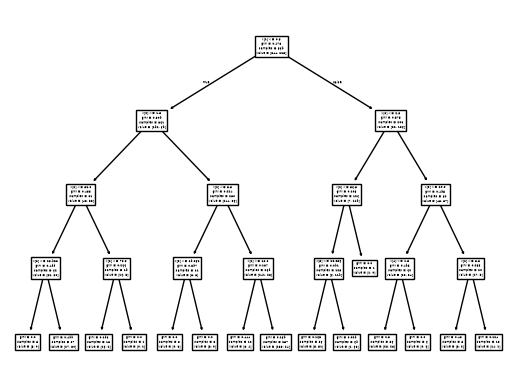

In [49]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import classification_report as cr
from sklearn.tree import DecisionTreeClassifier as dtc, plot_tree
d=sns.load_dataset('titanic')
d.columns
col=['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df=d[col]
df['sex']=df['sex'].map({'male': 0, 'female': 1})
df['embarked']=df['embarked'].map({'C': 0, 'Q': 1, 'S': 2})
df.dropna(inplace=True)
x=df.drop('survived',axis=1)
y=df['survived']
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=42)
dt=dtc(max_depth=4)
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)
print(cr(y_test,y_pred))
plot_tree(dt)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



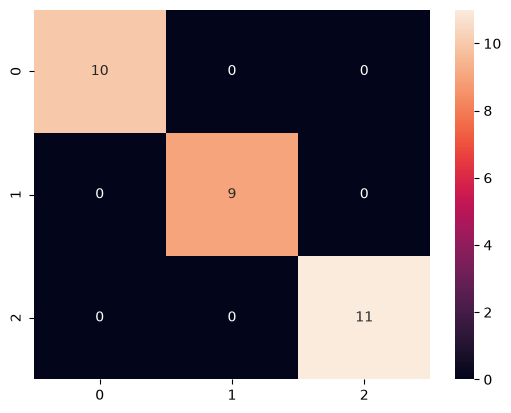

In [50]:
import seaborn as sns
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import classification_report as cr, confusion_matrix as cm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
df=load_iris()
x=df.data
y=df.target
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=42)
gnb=GaussianNB()
gnb.fit(x_train,y_train)
y_pred=gnb.predict(x_test)
print(cr(y_test,y_pred))
ccm=cm(y_test,y_pred)
sns.heatmap(ccm,annot=True)
plt.show()

Silhouette Score: 0.3433822406907781, Adjusted Rand Score: 0.6536246043910179


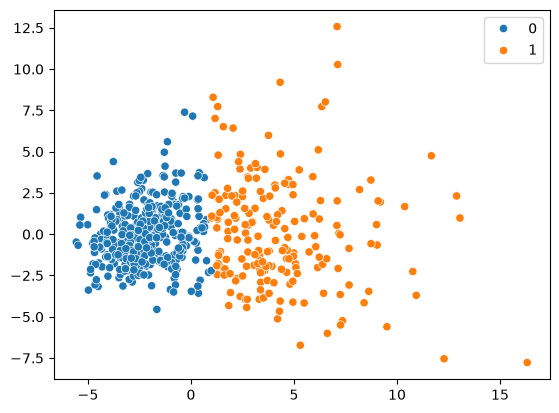

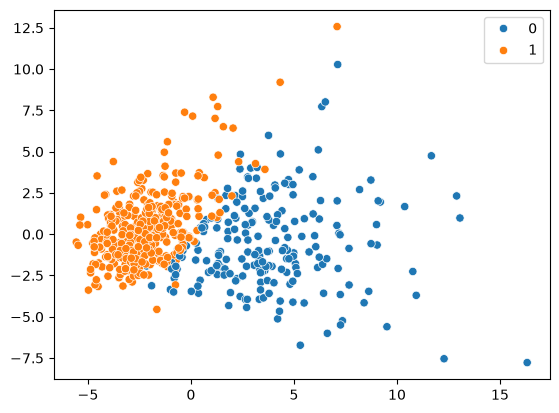

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split as tts
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import silhouette_score as ss, adjusted_rand_score as ars
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
df=load_breast_cancer()
x=pd.DataFrame(df.data,columns=df.feature_names)
y=df.target
s=StandardScaler()
x_s=s.fit_transform(x)
kmod=KMeans(n_clusters=2)
kmod.fit(x_s)
y_pred=kmod.fit_predict(x_s)
print(f"Silhouette Score: {ss(x_s,y_pred)}, Adjusted Rand Score: {ars(y,y_pred)}")
p=PCA(n_components=2)
pca=p.fit_transform(x_s)
sns.scatterplot(x=pca[:,0],y=pca[:,1],hue=y_pred)
plt.show()
sns.scatterplot(x=pca[:,0],y=pca[:,1],hue=y)
plt.show()
